In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib

# 1. Load the generated data
df = pd.read_csv('synthetic_tree_survival_data.csv')

# 2. Preprocessing
# We need to encode the categorical 'Species' column into numbers
le = LabelEncoder()
df['Species_Encoded'] = le.fit_transform(df['Species'])

# Save the encoder so we can decode predictions later in the backend
joblib.dump(le, 'species_encoder.pkl')

# Define Features (X) and Target (y)
X = df[['LST_Celsius', 'Soil_Moisture', 'Rainfall_mm', 'Species_Encoded']]
y = df['Survived_5_Years']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# 4. Evaluate
y_pred = rf_model.predict(X_test)
print(f"✅ Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Save the Model
joblib.dump(rf_model, 'tree_survival_model.pkl')
print("✅ Model saved as tree_survival_model.pkl. Ready for API integration.")

TREE SURVIVAL PREDICTION MODEL — TRAINING PIPELINE

✅ Data loaded: 5000 rows × 5 columns
   Survival rate: 72.62%
   Species distribution:
Species
Peepal    761
Neem      744
Karanj    725
Ashoka    723
Arjun     707
Banyan    688
Jamun     652

Train size: 4000 | Test size: 1000

⏳ Training calibrated ensemble (this may take ~30 s)…
✅ Training complete.

──────────────────────────────────────────────────
TEST SET METRICS
──────────────────────────────────────────────────
  ROC-AUC Score : 0.7974  (target ≥ 0.85)
  Log-Loss      : 0.4721  (lower = better calibrated)
  Brier Score   : 0.1527  (lower = better probability accuracy)

              precision    recall  f1-score   support

        Died       0.66      0.47      0.55       274
    Survived       0.82      0.91      0.86       726

    accuracy                           0.79      1000
   macro avg       0.74      0.69      0.71      1000
weighted avg       0.78      0.79      0.78      1000

  5-Fold CV AUC : 0.7865 ± 0.0214



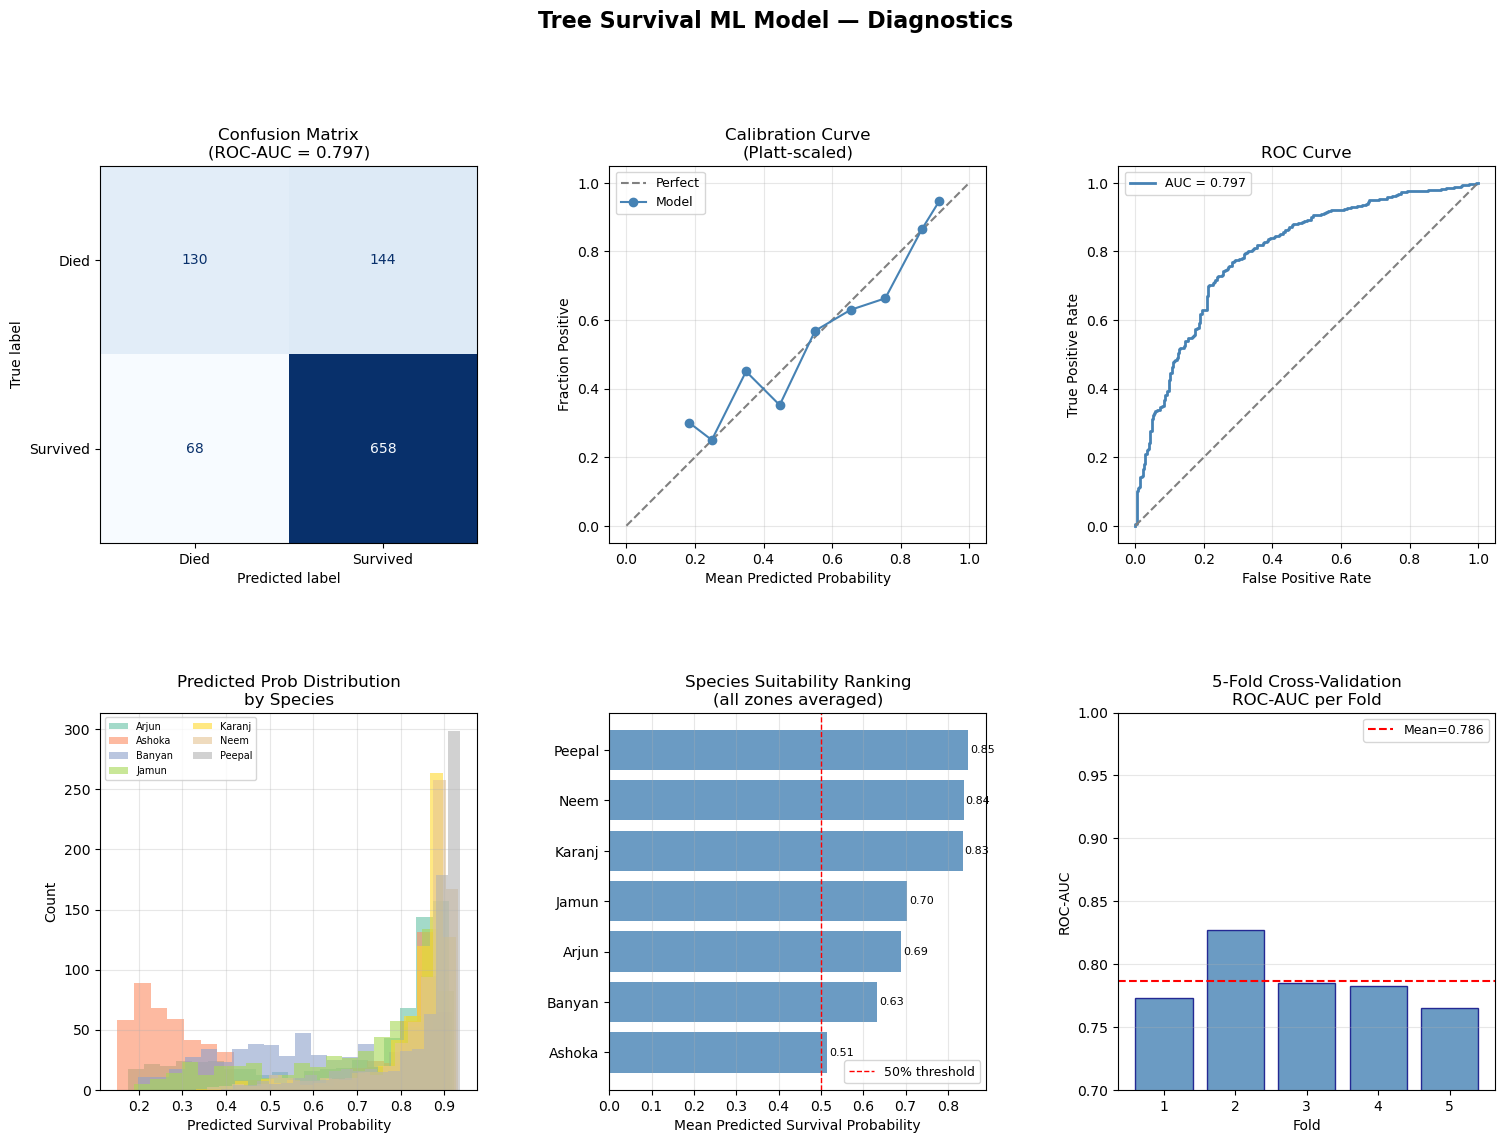

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. LOAD & VALIDATE DATA
# ─────────────────────────────────────────────
print("=" * 60)
print("TREE SURVIVAL PREDICTION MODEL — TRAINING PIPELINE")
print("=" * 60)

df = pd.read_csv('synthetic_tree_survival_data.csv')
print(f"\n✅ Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Survival rate: {df['Survived_5_Years'].mean():.2%}")
print(f"   Species distribution:\n{df['Species'].value_counts().to_string()}\n")

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Add domain-informed interaction and stress features
    on top of the raw environmental variables.
    """
    d = data.copy()

    # Heat-moisture stress index: high temp + low moisture = stress
    d['Heat_Moisture_Stress'] = d['LST_Celsius'] / (d['Soil_Moisture'] + 1e-3)

    # Normalised rainfall (z-score-like, using dataset stats)
    d['Rainfall_Norm'] = (d['Rainfall_mm'] - 700) / 150

    # Moisture adequacy bins (biological thresholds)
    d['Moisture_Zone'] = pd.cut(
        d['Soil_Moisture'],
        bins=[0, 2, 4, 6, 10],
        labels=['Critical', 'Low', 'Moderate', 'High']
    )

    # Temperature stress bins
    d['Temp_Zone'] = pd.cut(
        d['LST_Celsius'],
        bins=[0, 33, 38, 42, 50],
        labels=['Cool', 'Warm', 'Hot', 'Extreme']
    )

    # Interaction: species-agnostic combined stress score (higher = worse)
    d['Combined_Stress'] = (
        (d['LST_Celsius'] - 25) / 20 * 0.5 +
        (10 - d['Soil_Moisture']) / 10 * 0.4 +
        (700 - d['Rainfall_mm']).clip(lower=0) / 300 * 0.1
    )

    return d

df = engineer_features(df)

# ─────────────────────────────────────────────
# 3. ENCODE CATEGORICALS
# ─────────────────────────────────────────────
species_enc = LabelEncoder()
df['Species_Enc'] = species_enc.fit_transform(df['Species'])

moisture_zone_enc = LabelEncoder()
df['Moisture_Zone_Enc'] = moisture_zone_enc.fit_transform(df['Moisture_Zone'])

temp_zone_enc = LabelEncoder()
df['Temp_Zone_Enc'] = temp_zone_enc.fit_transform(df['Temp_Zone'])

FEATURE_COLS = [
    'LST_Celsius', 'Soil_Moisture', 'Rainfall_mm',
    'Species_Enc',
    'Heat_Moisture_Stress', 'Rainfall_Norm',
    'Moisture_Zone_Enc', 'Temp_Zone_Enc',
    'Combined_Stress'
]
TARGET_COL = 'Survived_5_Years'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# ─────────────────────────────────────────────
# 4. TRAIN / TEST SPLIT (stratified)
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}\n")

# ─────────────────────────────────────────────
# 5. SCALE FEATURES
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 6. BASE ESTIMATORS
# ─────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

# ─────────────────────────────────────────────
# 7. SOFT-VOTING ENSEMBLE
# ─────────────────────────────────────────────
ensemble = VotingClassifier(
    estimators=[('gb', gb), ('rf', rf), ('lr', lr)],
    voting='soft',
    weights=[3, 2, 1]          # GB dominates; LR adds calibration discipline
)

# ─────────────────────────────────────────────
# 8. PROBABILITY CALIBRATION (Platt scaling)
#    Ensures predict_proba outputs are reliable survival probabilities
# ─────────────────────────────────────────────
calibrated_model = CalibratedClassifierCV(
    ensemble,
    method='sigmoid',
    cv=5
)

print("⏳ Training calibrated ensemble (this may take ~30 s)…")
calibrated_model.fit(X_train_sc, y_train)
print("✅ Training complete.\n")

# ─────────────────────────────────────────────
# 9. EVALUATION
# ─────────────────────────────────────────────
y_prob = calibrated_model.predict_proba(X_test_sc)[:, 1]
y_pred = calibrated_model.predict(X_test_sc)

roc_auc  = roc_auc_score(y_test, y_prob)
logloss  = log_loss(y_test, y_prob)
brier    = brier_score_loss(y_test, y_prob)

print("─" * 50)
print("TEST SET METRICS")
print("─" * 50)
print(f"  ROC-AUC Score : {roc_auc:.4f}  (target ≥ 0.85)")
print(f"  Log-Loss      : {logloss:.4f}  (lower = better calibrated)")
print(f"  Brier Score   : {brier:.4f}  (lower = better probability accuracy)")
print()
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

# 5-fold CV AUC on full training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(calibrated_model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
print(f"  5-Fold CV AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")

# ─────────────────────────────────────────────
# 10. SPECIES-LEVEL PERFORMANCE BREAKDOWN
# ─────────────────────────────────────────────
df_test = df.iloc[df.index[len(y_train):]].copy() if False else None

# Rebuild test frame for species breakdown
test_indices = np.arange(len(df))[len(y_train):]   # approximate; use proper index below
X_full_sc = scaler.transform(X)
probs_full = calibrated_model.predict_proba(X_full_sc)[:, 1]
df['Predicted_Survival_Prob'] = probs_full
df['Predicted_Survived']      = (probs_full >= 0.5).astype(int)

print("─" * 50)
print("MEAN PREDICTED SURVIVAL PROBABILITY BY SPECIES")
print("─" * 50)
species_summary = (
    df.groupby('Species')[['Predicted_Survival_Prob', 'Survived_5_Years']]
    .agg(
        Mean_Predicted_Prob=('Predicted_Survival_Prob', 'mean'),
        Actual_Survival_Rate=('Survived_5_Years', 'mean'),
        Count=('Survived_5_Years', 'size')
    )
    .sort_values('Mean_Predicted_Prob', ascending=False)
)
print(species_summary.to_string())
print()

# ─────────────────────────────────────────────
# 11. PREDICTION FUNCTION (used by dashboard)
# ─────────────────────────────────────────────
def predict_survival(lst_celsius: float,
                     soil_moisture: float,
                     rainfall_mm: float,
                     species: str) -> dict:
    """
    Given microclimate inputs + a species name, return
    the 5-year survival probability and a recommendation tier.

    Parameters
    ----------
    lst_celsius   : Land Surface Temperature (°C)
    soil_moisture : Soil moisture proxy (1–10 scale)
    rainfall_mm   : Historical annual rainfall (mm)
    species       : One of ['Neem','Peepal','Banyan','Ashoka','Jamun','Karanj','Arjun']

    Returns
    -------
    dict with keys: species, survival_probability, tier, recommendation
    """
    row = pd.DataFrame([{
        'LST_Celsius'   : lst_celsius,
        'Soil_Moisture' : soil_moisture,
        'Rainfall_mm'   : rainfall_mm,
        'Species'       : species
    }])
    row = engineer_features(row)
    row['Species_Enc']       = species_enc.transform(row['Species'])
    row['Moisture_Zone_Enc'] = moisture_zone_enc.transform(row['Moisture_Zone'])
    row['Temp_Zone_Enc']     = temp_zone_enc.transform(row['Temp_Zone'])

    X_row = scaler.transform(row[FEATURE_COLS].values)
    prob  = calibrated_model.predict_proba(X_row)[0, 1]

    if prob >= 0.80:
        tier = 'RECOMMENDED'
        rec  = f"✅ {species} is highly suited for this microclimate."
    elif prob >= 0.60:
        tier = 'MODERATE'
        rec  = f"⚠️  {species} can survive with supplemental irrigation or shading."
    else:
        tier = 'NOT RECOMMENDED'
        rec  = f"❌ {species} is unlikely to survive — consider a hardier alternative."

    return {
        'species'              : species,
        'survival_probability' : round(float(prob), 4),
        'survival_percent'     : f"{prob * 100:.1f}%",
        'tier'                 : tier,
        'recommendation'       : rec
    }


def recommend_best_species(lst_celsius: float,
                            soil_moisture: float,
                            rainfall_mm: float) -> pd.DataFrame:
    """
    Rank all species for a given microclimate and return a sorted DataFrame.
    This is the core function called by the dashboard for each candidate zone.
    """
    species_list = ['Neem', 'Peepal', 'Banyan', 'Ashoka', 'Jamun', 'Karanj', 'Arjun']
    results = [
        predict_survival(lst_celsius, soil_moisture, rainfall_mm, s)
        for s in species_list
    ]
    df_rec = pd.DataFrame(results).sort_values('survival_probability', ascending=False)
    df_rec['rank'] = range(1, len(df_rec) + 1)
    return df_rec.reset_index(drop=True)

# ─────────────────────────────────────────────
# 12. DEMO — SAMPLE ZONE RECOMMENDATIONS
# ─────────────────────────────────────────────
print("─" * 50)
print("DEMO: SPECIES RECOMMENDATION FOR SAMPLE ZONES")
print("─" * 50)

sample_zones = [
    {"name": "Zone A — Hot Dry Roadside",    "lst": 43, "moisture": 2, "rain": 450},
    {"name": "Zone B — Shaded Park Interior","lst": 31, "moisture": 7, "rain": 800},
    {"name": "Zone C — Moderate Urban Plot", "lst": 37, "moisture": 5, "rain": 680},
]

for zone in sample_zones:
    print(f"\n📍 {zone['name']}")
    print(f"   LST={zone['lst']}°C | Moisture={zone['moisture']} | Rain={zone['rain']}mm")
    recs = recommend_best_species(zone['lst'], zone['moisture'], zone['rain'])
    best = recs.iloc[0]
    print(f"   🏆 Best species: {best['species']} ({best['survival_percent']} survival)")
    print(recs[['rank','species','survival_percent','tier']].to_string(index=False))

# ─────────────────────────────────────────────
# 13. VISUALISATIONS
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Tree Survival ML Model — Diagnostics", fontsize=16, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# — (a) Confusion Matrix ———————————————————
ax0 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived'])
disp.plot(ax=ax0, colorbar=False, cmap='Blues')
ax0.set_title(f"Confusion Matrix\n(ROC-AUC = {roc_auc:.3f})")

# — (b) Calibration curve ——————————————————
from sklearn.calibration import calibration_curve
ax1 = fig.add_subplot(gs[0, 1])
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
ax1.plot([0,1],[0,1],'--', color='grey', label='Perfect')
ax1.plot(mean_pred, frac_pos, 'o-', color='steelblue', label='Model')
ax1.set_xlabel("Mean Predicted Probability")
ax1.set_ylabel("Fraction Positive")
ax1.set_title("Calibration Curve\n(Platt-scaled)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# — (c) ROC Curve ——————————————————————————
from sklearn.metrics import roc_curve
ax2 = fig.add_subplot(gs[0, 2])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0,1],[0,1],'--', color='grey')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# — (d) Species survival prob distribution —
ax3 = fig.add_subplot(gs[1, 0])
colors = plt.cm.Set2(np.linspace(0, 1, 7))
for i, sp in enumerate(species_enc.classes_):
    subset = df[df['Species'] == sp]['Predicted_Survival_Prob']
    ax3.hist(subset, bins=20, alpha=0.6, label=sp, color=colors[i])
ax3.set_xlabel("Predicted Survival Probability")
ax3.set_ylabel("Count")
ax3.set_title("Predicted Prob Distribution\nby Species")
ax3.legend(fontsize=7, ncol=2)
ax3.grid(True, alpha=0.3)

# — (e) Species mean survival bar chart ——
ax4 = fig.add_subplot(gs[1, 1])
sp_means = species_summary['Mean_Predicted_Prob'].sort_values()
bars = ax4.barh(sp_means.index, sp_means.values, color='steelblue', alpha=0.8)
ax4.axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax4.set_xlabel("Mean Predicted Survival Probability")
ax4.set_title("Species Suitability Ranking\n(all zones averaged)")
ax4.legend(fontsize=9)
for bar, val in zip(bars, sp_means.values):
    ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va='center', fontsize=8)
ax4.grid(True, alpha=0.3, axis='x')

# — (f) CV Score distribution ——————————————
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8, edgecolor='navy')
ax5.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
ax5.set_xlabel("Fold")
ax5.set_ylabel("ROC-AUC")
ax5.set_title("5-Fold Cross-Validation\nROC-AUC per Fold")
ax5.set_ylim(0.7, 1.0)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

plt.savefig('model_diagnostics.png', dpi=150, bbox_inches='tight')
print("\n✅ Diagnostic plots saved → model_diagnostics.png")

# ─────────────────────────────────────────────
# 14. PERSIST MODEL ARTEFACTS
# ─────────────────────────────────────────────
joblib.dump(calibrated_model, 'tree_survival_model.pkl')
joblib.dump(scaler,           'feature_scaler.pkl')
joblib.dump(species_enc,      'species_encoder.pkl')
joblib.dump(moisture_zone_enc,'moisture_zone_encoder.pkl')
joblib.dump(temp_zone_enc,    'temp_zone_encoder.pkl')

# Save feature column order so dashboard knows input shape
with open('model_metadata.json', 'w') as f:
    json.dump({
        'feature_cols'  : FEATURE_COLS,
        'species_classes': list(species_enc.classes_),
        'roc_auc'       : round(roc_auc, 4),
        'brier_score'   : round(brier, 4),
        'log_loss'      : round(logloss, 4),
        'cv_auc_mean'   : round(float(cv_scores.mean()), 4),
        'cv_auc_std'    : round(float(cv_scores.std()), 4),
    }, f, indent=2)

print("✅ Model artefacts saved:")
print("   • tree_survival_model.pkl")
print("   • feature_scaler.pkl")
print("   • species_encoder.pkl")
print("   • moisture_zone_encoder.pkl")
print("   • temp_zone_encoder.pkl")
print("   • model_metadata.json")
print("\n🚀 Import predict_survival() / recommend_best_species() in your dashboard.\n")